# Sprint 6. Proyecto integrado 1

### File and data

#### Import the libraries

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as st

#### Upload the file

In [19]:
df_games = pd.read_csv(r'C:\Users\Jorge\Downloads\games.csv')

#### Exploratory data analysis

In [20]:
#Observar los datos, valores nulos y tipos de datos.

df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


### Data cleaning

#### Change column names to lowercase

In [21]:
df_games.columns = df_games.columns.str.lower()

print(df_games.info())

df_games

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


#### Convert data 


In [22]:
#Convert the column data 'year_of_release' to integer
df_games['year_of_release'] = pd.to_numeric(df_games['year_of_release'], errors='coerce')
print("Column 'year_of_release' type:", df_games['year_of_release'].dtypes)

#Convert the column data 'critic_score' to integer
df_games['critic_score'] = pd.to_numeric(df_games['critic_score'], errors='coerce')
print("Column 'critic_score' type:", df_games['critic_score'].dtypes)
#Review for NaN values in 'user_score'  
print("Empty values in 'user_score':", df_games['user_score'].isna().sum())

#Convert the column data 'critic_score' to float
df_games['user_score'] = pd.to_numeric(df_games['user_score'], errors='coerce')
print("Column 'user_score' type:", df_games['user_score'].dtypes)

print()

df_games.info()

Column 'year_of_release' type: float64
Column 'critic_score' type: float64
Empty values in 'user_score': 6701
Column 'user_score' type: float64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: float64(7), object(4)
memory usage: 1.4+ MB


#### Describe the columns in which the data types have been changed and explain why.

Se decidió cambiar el tipo de dato para las columnas 'year_of_release' y 'critic_score' debido a que el tipo dato que tenían no coincidían con los datos presentes en dichas columnas (números enteros).

### Empty data

In [23]:
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: float64(7), object(4)
memory usage: 1.4+ MB


In [24]:
#Fill missing values in 'name' with 'Unknown'
print("Empty values in 'name' at the start:", df_games['name'].isna().sum())
df_games['name'] = df_games['name'].fillna('Unknown')
print("Empty values in 'name' at the end:", df_games['name'].isna().sum())

Empty values in 'name' at the start: 2
Empty values in 'name' at the end: 0


In [25]:
#Fill missing values in 'genre' with 'Unknown'
print("Empty values in 'genre' at the start:", df_games['genre'].isna().sum())
df_games['genre'] = df_games['genre'].fillna('Unknown')
print("Empty values in 'genre' at the end:", df_games['genre'].isna().sum())

Empty values in 'genre' at the start: 2
Empty values in 'genre' at the end: 0


Missgin data has been filled for 'name' and 'genre' columns with 'Unknown', now there are no empty values in these columns.

Other columns with missing data will be left as they are, since filling them with mean/median/mode or deleting rows may affect the analysis.

Probably, columns with missing data coulb be empty due to missing information about the videogame as reviews, rate or critics.

Finally, the TBD data weere changed for NaN.

#### Total sales

In [26]:
df_games['total_sales'] = df_games[['eu_sales', 'jp_sales', 'na_sales', 'other_sales']].sum(axis = 1)

df_games

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN,0.01
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN,0.01


### Data Analysis

#### Analyzes the number of video games released per year

Number of rows without year of release: 269


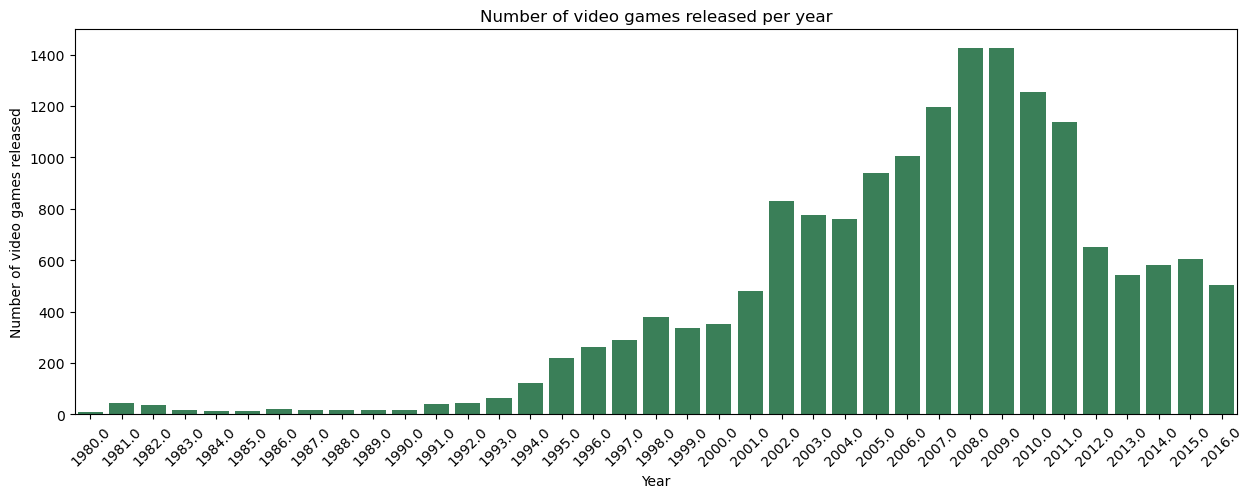

In [ ]:
print('Number of rows without year of release:', df_games['year_of_release'].isna().sum())


games_without_yor = df_games[~df_games['year_of_release'].isna()]
games_per_year = games_without_yor.groupby('year_of_release').size().reset_index(name='count')


plt.figure(figsize=(15, 5))
sns.barplot(data = games_per_year, x = 'year_of_release', y ='count', color = 'seagreen')
plt.title('Number of video games released per year')
plt.xlabel('Year')
plt.ylabel('Number of video games released')
plt.xticks(rotation=45)
print('Number of rows without year of release:', df_games['year_of_release'].isna().sum())


games_without_yor = df_games[~df_games['year_of_release'].isna()]plt.show()

#### Analyze the total sales of different video game platforms

Number of rows without sales data: 0


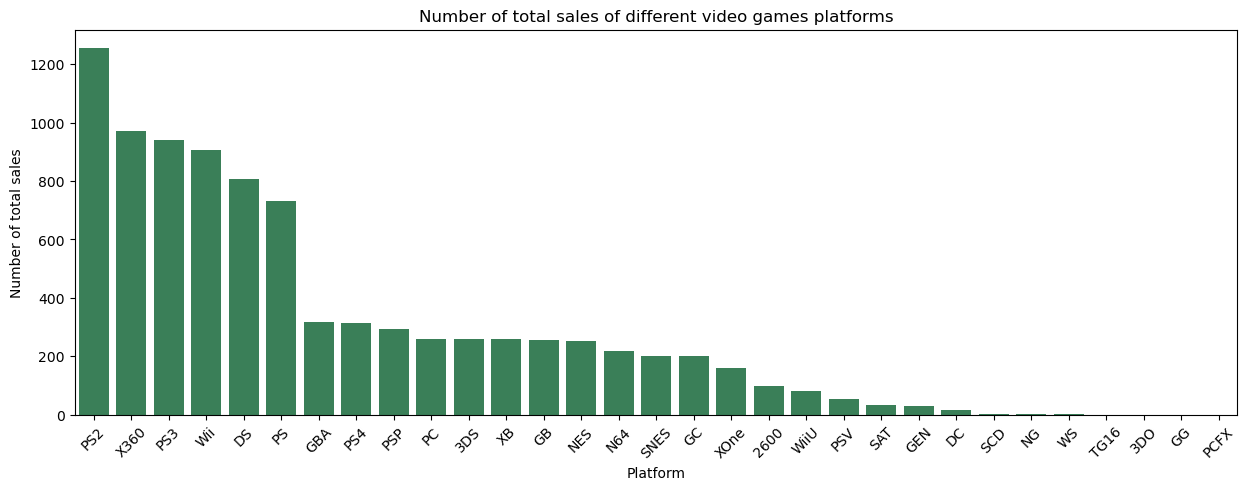

In [59]:
print('Number of rows without sales data:', df_games['total_sales'].isna().sum())

platform_sales = df_games.groupby('platform')['total_sales'].sum().reset_index(name='count').sort_values('count', ascending = False)


plt.figure(figsize=(15, 5))
sns.barplot(data = platform_sales, x = 'platform', y ='count', color = 'seagreen')
plt.title('Number of total sales of different video games platforms')
plt.xlabel('Platform')
plt.ylabel('Number of total sales')
plt.xticks(rotation=45)
plt.show()